In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nltk.stem import PorterStemmer
from sklearn.base import BaseEstimator, TransformerMixin
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, f1_score
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
!pip install lime
from lime.lime_text import LimeTextExplainer
import joblib
import zipfile
!pip install shap
import shap
from scipy.special import softmax



In [2]:
# import training and test datasets
train_df = pd.read_csv('dreaddit-train.csv')
test_df = pd.read_csv('dreaddit-test.csv')

## Data Pre-processing
We include the category of the subreddits as an added column as defined by the Dreaddit paper:

(1) Abuse - r/domesticviolence, r/survivorsofabuse

(2) Anxiety - r/anxiety, r/stress

(3) Financial - r/almosthomeless, r/assistance, r/foodpantry, r/homeless

(4) PTSD - r/ptsd

(5) Social - r/relationships

In [3]:
# Add in subreddit category
df_list = [train_df, test_df]
for df in df_list:
    conditions = [
    df['subreddit'] == 'domesticviolence',
    df['subreddit'] == 'survivorsofabuse',
    df['subreddit'] == 'anxiety',
    df['subreddit'] == 'stress',
    df['subreddit'] == 'almosthomeless',
    df['subreddit'] == 'assistance',
    df['subreddit'] == 'food_pantry',
    df['subreddit'] == 'homeless',
    df['subreddit'] == 'ptsd',
    df['subreddit'] == 'relationships'
    ]
    choices = ['abuse', 'abuse', 'anxiety', 'anxiety', 'financial', 'financial',
            'financial', 'financial', 'ptsd', 'social']

    df['category'] = np.select(conditions, choices, default='unknown')

## Training Data Visualisation
The training data has 1350 non-stress (class 0) datapoints and 1488 stress (class 1) datapoints. The subreddit categories are also balanced with around 550 records for each category. Hence, we assume that the training dataset is balanced.

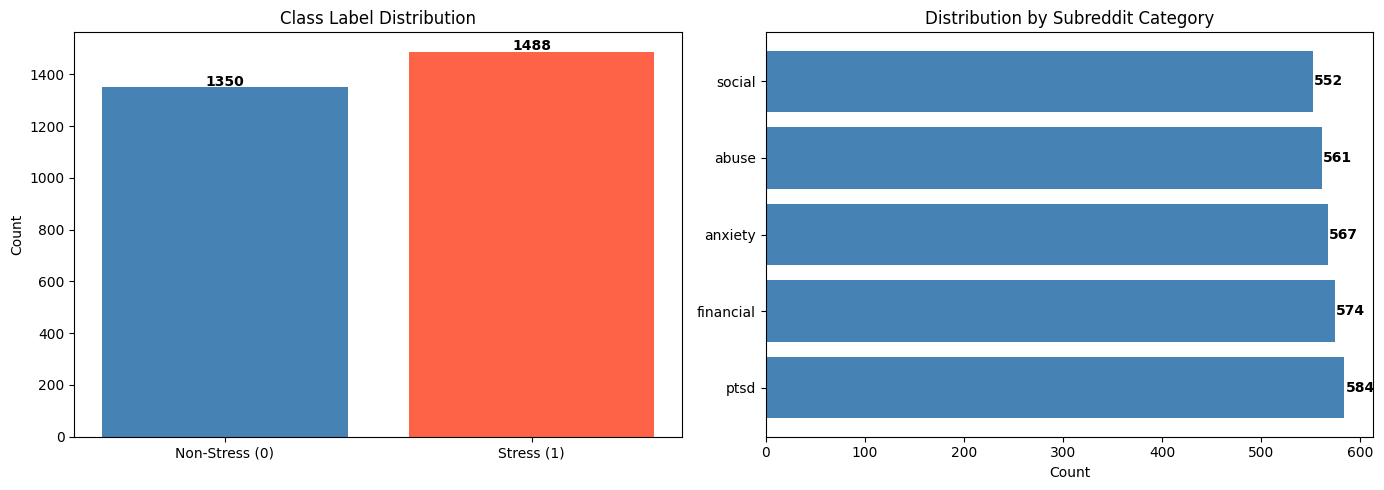

Class label breakdown:
  0: 1350 (47.6%)
  1: 1488 (52.4%)

Category breakdown:
  ptsd: 584 (20.6%)
  financial: 574 (20.2%)
  anxiety: 567 (20.0%)
  abuse: 561 (19.8%)
  social: 552 (19.5%)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class label distribution
label_counts = train_df['label'].value_counts().sort_index()
axes[0].bar(['Non-Stress (0)', 'Stress (1)'], label_counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Class Label Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Category distribution
category_counts = train_df['category'].value_counts()
axes[1].barh(category_counts.index, category_counts.values, color='steelblue')
axes[1].set_title('Distribution by Subreddit Category')
axes[1].set_xlabel('Count')
for i, v in enumerate(category_counts.values):
    axes[1].text(v + 1, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Print percentages
print("Class label breakdown:")
for label, count in label_counts.items():
    print(f"  {label}: {count} ({count/len(train_df)*100:.1f}%)")

print("\nCategory breakdown:")
for cat, count in category_counts.items():
    print(f"  {cat}: {count} ({count/len(train_df)*100:.1f}%)")

## Test Dataset Visualisation
Similarly, the test dataset is balanced across class labels and subreddit categories.

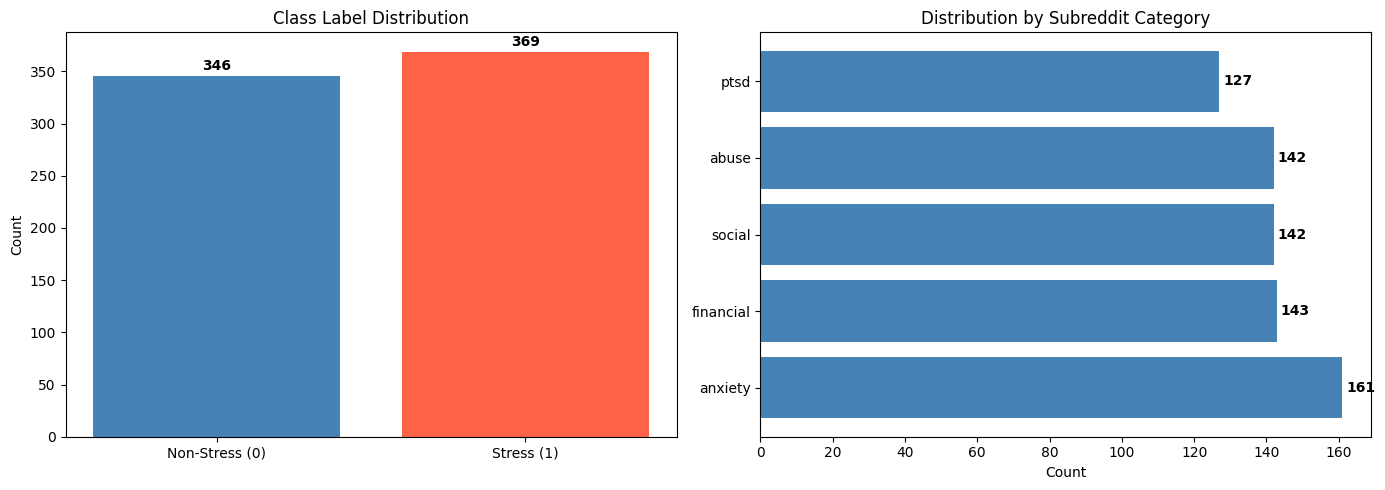

Class label breakdown:
  0: 346 (48.4%)
  1: 369 (51.6%)

Category breakdown:
  anxiety: 161 (22.5%)
  financial: 143 (20.0%)
  social: 142 (19.9%)
  abuse: 142 (19.9%)
  ptsd: 127 (17.8%)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class label distribution
label_counts = test_df['label'].value_counts().sort_index()
axes[0].bar(['Non-Stress (0)', 'Stress (1)'], label_counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Class Label Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Category distribution
category_counts = test_df['category'].value_counts()
axes[1].barh(category_counts.index, category_counts.values, color='steelblue')
axes[1].set_title('Distribution by Subreddit Category')
axes[1].set_xlabel('Count')
for i, v in enumerate(category_counts.values):
    axes[1].text(v + 1, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Print percentages
print("Class label breakdown:")
for label, count in label_counts.items():
    print(f"  {label}: {count} ({count/len(test_df)*100:.1f}%)")

print("\nCategory breakdown:")
for cat, count in category_counts.items():
    print(f"  {cat}: {count} ({count/len(test_df)*100:.1f}%)")

# Baseline Model - TF-IDF with Logistic Regression
## Pre-processing
First, convert the text data into suitable datatypes for TF-IDF. Next, use stemming to keep only the root words. We do this outside of the model pipeline since stemming is deterministic and will not cause data leakage, hence saving time during cross validation. Then, during the tf-idf vectorisation process, we convert text into lowercase, keep words with apostrophes and do a log transform on the term frequency.

## Hyperparameter tuning and cross validation
We have 4 hyperparameters:

(1) tfidf__ngram_range controls what size chunks of words the vectoriser treats as features. We have 2 ranges: (1, 2) and (3, 5)

(2) tfidf__min_df sets the minimum number of documents a term must appear in to be included. Higher values reduce noise and speed things up but risk dropping rare but meaningful terms. We test 2 values: 2 and 5

(3) tfidf__max_df drops terms that appear in more than X% of documents. We test 0.8 and 0.9.

(4) clf__C is the regularisation strength for logistic regression — it controls how much the model is penalised for overfitting. A low C applies strong regularisation, keeping weights small and the model simpler while a high C applies weak regularisation, allowing greater model flexibility. We test 4 values: 0.01, 0.1, 1.0, 10.0.

This gives 32 possible permutations to test using Grid Search.

We also perform 5-fold cross validation, resulting in 32*5 = 160 runs.

## Model Architecture and Limitations
We start with a simpler, baseline model as a benchmark that is still very interpretable due to the bag of words approach.

TF-IDF is a statistical feature extraction method that converts raw text into a sparse numerical vector. Each dimension in the vector corresponds to a unique token in the vocabulary. The value assigned to each token is a product of two things: how frequently it appears in the current document (Term Frequency), and how rare it is across all documents (Inverse Document Frequency). This means common words that appear everywhere get downweighted while distinctive terms that appear in only a few posts get upweighted.

This is logical for finding key terms that indicate stress as these would be rarer words that are still commonly found across the entire dataset since the dataset is likely to contain similar sentiments indicating stress.

However, TF-IDF has no notion of word order or context. "I am not stressed" and "I am stressed" would produce very similar vectors despite having opposite meanings, which is a significant shortcoming for stress detection.

Logistic Regression learns a weight for every feature makes predictions by taking a weighted sum of the input features and passing it through a sigmoid function to produce a probability. It is very interpretable due to the linear boundary, but assumes that the contribution of each word to the prediction is independent of all other words. This ignores the relationship between words which runs into the same problem as TF-IDF.

In [6]:
# Convert datatypes
X_text = train_df['text'].astype(str)
y = train_df['label'].astype(int)

X_test_text = test_df['text'].astype(str)
y_test = test_df['label'].astype(int)

# Stemming functionality
nltk.download('punkt_tab')

class TextNormaliser(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.stemmer = PorterStemmer()

    def normalise(self, text):
        tokens = nltk.word_tokenize(text.lower())
        return ' '.join(self.stemmer.stem(t) for t in tokens)

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return [self.normalise(text) for text in X]

# Stemming on training and test set done before hyperparameter tuning since it is deterministic
normaliser = TextNormaliser()
X_text_stemmed = pd.Series(normaliser.transform(X_text))
X_test_text_stemmed = pd.Series(normaliser.transform(X_test_text))

# --- Define pipeline ---
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        sublinear_tf=True,
        token_pattern=r"(?u)\b[\w']+\b"
    )),
    ('clf', LogisticRegression(
        solver='liblinear',
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

# --- Hyperparameter search space ---
param_grid = {
    'tfidf__ngram_range': [(1, 2),(3, 5)],
    'tfidf__min_df':      [2, 5],
    'tfidf__max_df':      [0.8, 0.9],
    'clf__C':             [0.01, 0.1, 1.0, 10.0],
}

# --- K-Fold CV (on training data only) ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    refit=True   # refit best model on full training set after search
)

grid_search.fit(X_text, y)  # hyperparameter tuning only sees train_df data

print("Best parameters:", grid_search.best_params_)
print("Best CV F1-score:", grid_search.best_score_)



[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters: {'clf__C': 0.01, 'tfidf__max_df': 0.8, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}
Best CV F1-score: 0.7849818685614047


## TF-IDF Logistic Regression Model Evaluation
After the grid search, we find the best model with an F1 score of 0.785 using the parameters: {'clf__C': 0.01, 'tfidf__max_df': 0.8, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}. This means that 1) the logistic regression has a strict regularisation, 2) any token appearing in fewer than 2 documents is discarded, 3) phrases cannot appear more than in 80% of all datapoints and 4) phrases are restricted to 1 or 2 words.

When predicting on the unseen test dataset, we get an F1 score of 0.744 for stress-indicative class labels and 0.667 for non-stress-indicative class labels.

In [7]:
# --- Final evaluation on held-out test set ---
best_model = grid_search.best_estimator_

y_test_pred = best_model.predict(X_test_text)
y_test_prob = best_model.predict_proba(X_test_text)[:, 1]

print("\n=== Test Set Evaluation ===")
print(classification_report(y_test, y_test_pred, digits=3))
print("F1-score:", f1_score(y_test, y_test_pred))


=== Test Set Evaluation ===
              precision    recall  f1-score   support

           0      0.753     0.598     0.667       346
           1      0.684     0.816     0.744       369

    accuracy                          0.710       715
   macro avg      0.718     0.707     0.705       715
weighted avg      0.717     0.710     0.707       715

F1-score: 0.7441285537700866


In [8]:
# Save
joblib.dump(best_model, 'stress_baseline_model.pkl')

# Load
best_model = joblib.load('stress_baseline_model.pkl')

## Baseline Model Global Analysis

### Breakdown of Stress-indicative terms found by model

#### Theory
The logistic regression model assigns a weight to every token in the TF-IDF vocabulary. A large positive coefficient means that token strongly pushes the model towards predicting stress, while a large negative coefficient means it pushes towards predicting no stress.

We see from the stress-indicative terms what linguistic patterns the model has learned to associate with stress. We would expect to see terms related to anxiety, sleep problems, relationship issues, or negative self-talk appearing here. These should in theory, strongly tip the model towards a stress prediction.

The non-stress terms should show the opposite — language the model associates with calm or positive posts. These might be terms from more neutral or supportive subreddits in the dataset.

### Analysis of results

The stress terms are overwhelmingly first-person singular — "me", "my", "myself", "i'm", "i feel", "i don't". This suggests that stressed or depressed individuals tend to use more first-person singular language, focusing inward on themselves. Terms like "feel", "i feel", "feel like" suggest emotional self-reporting, while "can't", "i don't", "don't" indicate negative or helpless framing. "anxiety" appearing directly is unsurprising. "what to", "what to do" suggests confusion or feeling lost, which is consistent with stress.

The non-stress terms are dominated by second-person language — "you", "your", "you can", "if you" — suggesting outward-directed, other-focused communication which contrasts sharply with the inward focus of stressed posts. "thank", "thank you" indicate positive social interaction. "we" suggests community or collective thinking rather than isolated self-focus.

The overall pattern is that stress manifests as inward, self-focused, emotionally charged language while non-stress posts tend to be more outward-facing and socially engaged.

### Limitation
We see that our hypothesis of seeing rarer stress-related vocabulary did not seem to work, even with the restriction on n-grams being 1 to 2 words.

Also, because TF-IDF has no notion of context, the model may have picked up a particular subreddit's writing style rather than genuine stress language.

In [9]:
# Stress indicative features
tfidf_step = best_model.named_steps['tfidf']
clf_step = best_model.named_steps['clf']

feature_names = np.array(tfidf_step.get_feature_names_out())
coef = clf_step.coef_[0]

top_stress = feature_names[np.argsort(coef)[-20:]]
top_non_stress = feature_names[np.argsort(coef)[:20]]

print("Stress-indicative terms:\n", top_stress)
print("\nNon-stress terms:\n", top_non_stress)

Stress-indicative terms:
 ['like' 'myself' 'feel like' "can't" 'to do' 'what to' 'what' 'anxiety'
 'am' 'even' 'do' 'because' 'just' "i don't" "don't" 'i feel' "i'm" 'feel'
 'my' 'me']

Non-stress terms:
 ['you' 'we' 'your' 'her' 'url' 'she' 'if you' 'thank' 'thank you' 'would'
 'for' 'you can' 'survey' 'who' 'be' 'will' 'met' 'more' 'years' 'first']


## Baseline Model Local Analysis
### Using LIME - Local Interpretable Model-Agnostic Explanations

We look at the local level, which is specific datapoints to see what words influence the final decision. We look at cases where the confidence is around 50% to see the decision boundary of the model.

We see immediately that the stemming has significantly affected words with more letters, truncating them to non-english words.

Example 1 (wrong) — The stemmed text contains clearly distressing phrases like "wan na die", "helpless", "scare", yet the model predicted Non-Stress with only 50% confidence. Stemming has likely damaged some of these signals such as "scared" becoming "scare" and "wanting" becoming "wan", causing it to miss obvious stress indicators.

Example 2 (correct) — The content describes traumatic memories of an ex-partner and emotional distress, but again the confidence is only 50%. The model got it right but for the wrong reasons likely — terms like "terribl memori" and "could not stop" are present but stemming has fragmented enough of the natural phrasing that the model is essentially guessing.

Example 3 (correct) — The non-stress prediction is the most confident of the three at 50.81%, which is still very low. "Thank" is present which aligns with the non-stress terms identified earlier.

Overall takeaway — all three confidence values hovering just above 50% suggests the model is struggling significantly on these samples. This is likely a combined effect of stemming corrupting natural ngrams that the model was trained to recognise, and the fundamental limitation of TF-IDF losing contextual meaning. This motivates the move to a transformer model like RoBERTa which better understands context.

we 'd be save so much money with thi new housr ... it such an expens citi .... i did some googl in their languag and found that it wa illeg for them to do that . i wa excit like oh ok if it happen ill call the polic on them .... but now i did some further googl and turn out that if you sign the contract with that in it than everyth is on their side ... the contract is long term so we 'd have to give 6month notic befor leav even if we give it next week ill still have to live six month with thi .... i wan na die i swear i havent been so helpless and scare in so long .... also two day ago my friend mention he ran into my ex who ruin my life and that he told him he want to see mw and get closur .

--- Sample index 2 ---
True label:      Stress
Predicted label: Non-Stress
Confidence:      50.10%
Correct:         False


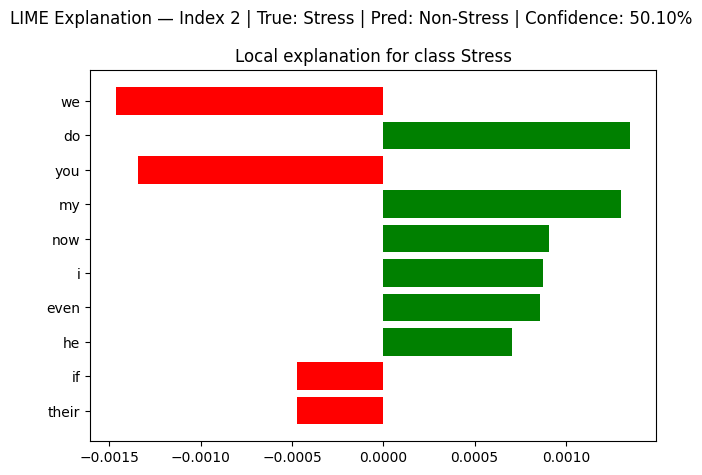

my ex use to shoot back with `` do you want me to go with you ? '' all the time , no matter what it wa . i almost wonder if i block out him ask me that about our own wed . i unload a terribl memori of thi on my current bf today and he took it like a champ , i just could not stop chase myself in circl over thi and knew if i heard ani sort of similar phrase i would lose it . i just need to throw thi out in the open , where other who might understand could 'hear ' it .

--- Sample index 3 ---
True label:      Stress
Predicted label: Stress
Confidence:      50.26%
Correct:         True


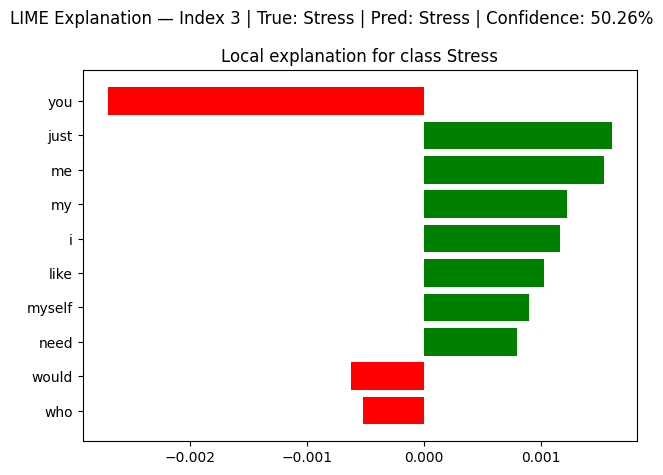

thank . edit 1 - fuel receipt as request . < url > sorri for the long respons , i went to spend the night at a friend becaus it got realli cold here ! the polic said they do n't give out a copi of the report but they gave me an incid number that can be use to verifi the report wa file .

--- Sample index 5 ---
True label:      Non-Stress
Predicted label: Non-Stress
Confidence:      50.81%
Correct:         True


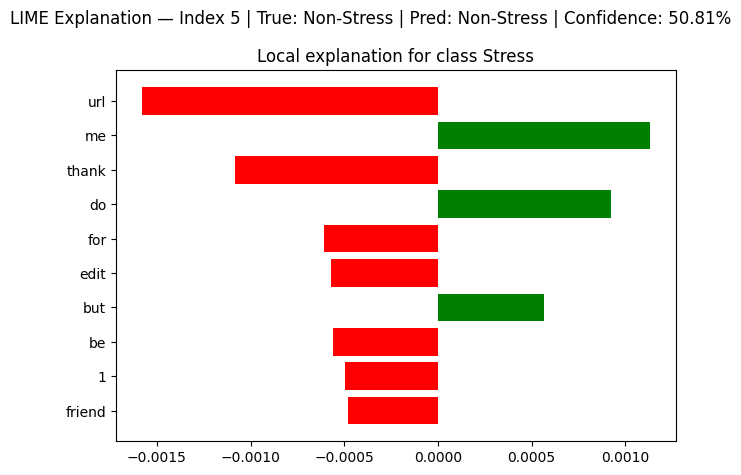

In [10]:
explainer = LimeTextExplainer(class_names=['Non-Stress', 'Stress'])

for idx in [2, 3, 5]:
    sample_text = X_test_text_stemmed.iloc[idx]
    print(sample_text)
    true_label = y_test.iloc[idx]
    pred_label = best_model.predict([sample_text])[0]
    pred_proba = best_model.predict_proba([sample_text])[0]
    confidence = pred_proba[pred_label]

    exp = explainer.explain_instance(
        sample_text,
        best_model.predict_proba,
        num_features=10
    )

    print(f"\n--- Sample index {idx} ---")
    print(f"True label:      {'Stress' if true_label == 1 else 'Non-Stress'}")
    print(f"Predicted label: {'Stress' if pred_label == 1 else 'Non-Stress'}")
    print(f"Confidence:      {confidence:.2%}")
    print(f"Correct:         {true_label == pred_label}")

    fig = exp.as_pyplot_figure()
    fig.suptitle(
        f"LIME Explanation — Index {idx} | "
        f"True: {'Stress' if true_label == 1 else 'Non-Stress'} | "
        f"Pred: {'Stress' if pred_label == 1 else 'Non-Stress'} | "
        f"Confidence: {confidence:.2%}"
    )
    plt.tight_layout()
    plt.show()

## Improved Model - Predicting Stress using finetuned mental-RoBERTa trained on dreaddit dataset

### Rationale
We move on to roBERTa, which uses dynamic masking, which helps the model learn more robust linguistic patterns. For mental health detection, where nuance, negation (e.g., "I'm not okay"), and context are important, RoBERTa's deep bidirectional understanding is far superior to keyword-based models.

Since we have a small dataset of labelled data, we want our model to understand domain-specific terminology. Hence we use Mental-RoBERTa, which has been further pre-trained on a massive corpus of Reddit data from mental health subreddits.

We then finetune using the Dreaddit dataset for our specific task of classifying stress, thereby ensuring that the small dataset size does not affect performance.

### Limitations
roBERTa is much harder to interpret as a black box model. To extract insights, it is not deterministic in output so there is ambiguity involved. It is also very computationally expensive as a large model.

# NOTE:
I have omitted the training code from being run. Hence, to load the results and analysis, please place the zip folder in the same directory as the notebook, it will automatically be extracted in the code.

In [11]:
# from huggingface_hub import login
# login()
# !hf auth whoami

## Dataset processing and hyperparameter tuning

Unlike our previous TF-IDF Logistic Regression model which required extensive text cleaning, our RoBERTa-based pipeline utilizes raw text. This preserves the semantic integrity of the posts—allowing the model to capture nuances like negation and sentence flow which are critical for mental health detection.

Furthermore, we utilized the standard recommended hyperparameters for fine-tuning. Because we are using Mental-RoBERTa, which already possesses domain-specific knowledge of mental health language, the model converges rapidly without the need for exhaustive hyperparameter optimization.

The hugging face Trainer object handles the rest of the data processing for us.

In [12]:
'''
Function to tokenize text data
Input: string
Output: tokenized data
'''
def tokenize(texts):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors='pt'
    )

In [13]:
# Create RedditDataset object for easier retrieval of data and class labels
class RedditDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# model_name = "mental/mental-roberta-base"
# tokenizer = AutoTokenizer.from_pretrained(model_name)

# train_encodings = tokenize(list(X_train))
# val_encodings = tokenize(list(X_val))

# y_train = y_train.reset_index(drop=True)
# y_val = y_val.reset_index(drop=True)
# train_dataset = RedditDataset(train_encodings, list(y_train.values))
# val_dataset = RedditDataset(val_encodings, list(y_val.values))

In [14]:
# model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# def compute_metrics(eval_pred):
#     logits, labels = eval_pred
#     preds = np.argmax(logits, axis=1)
#     return {'f1': f1_score(labels, preds, average='binary')}

In [15]:
# training_args = TrainingArguments(
#     output_dir='./results',
#     num_train_epochs=3,
#     per_device_train_batch_size=16,
#     learning_rate=2e-5,
#     weight_decay=0.01,
#     eval_strategy='epoch',
#     save_strategy='epoch',
#     load_best_model_at_end=True,
#     metric_for_best_model='f1',
# )

# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=val_dataset,
#     compute_metrics=compute_metrics
# )

# trainer.train()

In [16]:
# from google.colab import files
# import shutil

## save trained model and tokenizer
# trainer.save_model('./my_model')
# tokenizer.save_pretrained('./my_model')

## zip the folder and download folder
# shutil.make_archive('my_model', 'zip', './my_model')
# files.download('my_model.zip')

## upload model to hugging face
#trainer.push_to_hub("PlacidWombat/dreadit-stress-classifier")

In [18]:
# Load trained model that has been saved for convenience
# Unzip to a folder named 'my_model'
with zipfile.ZipFile('my_model.zip', 'r') as zip_ref:
    zip_ref.extractall('my_model_folder')
model = AutoModelForSequenceClassification.from_pretrained('./my_model_folder')
tokenizer = AutoTokenizer.from_pretrained('./my_model_folder')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

### Results

With our finetuned mental-roBERTa model, we achieve an F1 score of 0.839 for Stressed data and 0.813 for Non-Stressed data. This improves upon the baseline TF-IDF Logistic Regression model by a significant amount.

In [19]:
# Predict class labels using test dataset
test_dataset = RedditDataset(tokenize(list(test_df['text'])), list(test_df['label']))
trainer = Trainer(model=model)
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)
print(classification_report(test_df['label'], preds, target_names=['Non-stressed', 'Stressed'], digits=3))

              precision    recall  f1-score   support

Non-stressed      0.851     0.777     0.813       346
    Stressed      0.807     0.873     0.839       369

    accuracy                          0.827       715
   macro avg      0.829     0.825     0.826       715
weighted avg      0.828     0.827     0.826       715



##  roBERTa Model Analysis

### Global Analysis by subreddit category
We analyse each subreddit category to see their individual F1-scores to determine which category is best predicted for Stress. Anxiety was best predicted, with an F1 score of 0.861. Social performed the worst, with an F1 score of 0.768.

As seen earlier, social understandly performs worse due to being expressed through interpersonal dynamics, not specific "trigger words". Because the model only sees these common phrases, it may struggle to distinguish between "I don't know what to wear" (Non-stressed) and "I don't know what to do about my toxic friend"

In [20]:
# Add the predictions to your test dataframe
test_df['predicted_label'] = preds

# Calculate accuracy/F1 per category
category_results = []
for cat in test_df['category'].unique():
    subset = test_df[test_df['category'] == cat]
    report = classification_report(subset['label'], subset['predicted_label'], output_dict=True, zero_division=0)

    category_results.append({
        'Category': cat,
        'F1-Score': report['weighted avg']['f1-score'],
        'Sample Size': len(subset)
    })

# Display as a sorted table
import pandas as pd
perf_df = pd.DataFrame(category_results).sort_values(by='F1-Score', ascending=False)
print(perf_df)

    Category  F1-Score  Sample Size
1    anxiety  0.861707          161
3  financial  0.847133          143
2       ptsd  0.839674          127
4      abuse  0.807183          142
0     social  0.767853          142


## SHAP

For further analysis, we performed a SHAP (SHapley Additive exPlanations) analysis on the test set's most confident predictions to see which specific words forced the model to make its decision.

In the Anxiety category, the model analyzed a post containing the word "anxieties". As shown in the SHAP heatmap, while the word "anx-ieties" did pull the prediction toward the "Stressed" class (blue bars), it was completely overwhelmed by the contextual signals of a moderator announcement. Words like "support", "others" provided massive positive weights toward the Non-Stressed label, contributing to the final prediction as non-stressed.

This proves the model understands intent. It distinguishes between having an anxiety attack and hosting a community thread about anxiety.

The Social category example is a complex narrative involving multiple characters.

Relationship posts are often long and filled with emotional words that can be ambiguous, yet, the model identified this as Non-Stressed with near-certainty. The SHAP analysis shows that the model ignored the potentially stressful names and "need to talk" phrasing, and instead focused on the resolution phase of the post. The phrases "thanks to everybody", "gave comfort", and "thank you to everyone" were the primary drivers.

The model is not just looking for social conflict but it is also successfully identifying "social support" and "emotional resolution," which are key markers of the Non-Stressed class in the Dreaddit dataset.

In [22]:
# Convert raw logits to probabilities
probs = softmax(predictions.predictions, axis=1)
test_df['model_confidence'] = np.max(probs, axis=1)
test_df['predicted_label'] = np.argmax(probs, axis=1)

# Find the #1 most confident post for Anxiety and Social
top_anxiety = test_df[test_df['category'] == 'anxiety'].sort_values('model_confidence', ascending=False).iloc[0]
top_social = test_df[test_df['category'] == 'social'].sort_values('model_confidence', ascending=False).iloc[0]

print(f"--- Top Anxiety Post (Confidence: {top_anxiety['model_confidence']:.4f}) ---")
print(f"Class label: Non-Stress")
print(top_anxiety['text'])

print(f"\n--- Top Social Post (Confidence: {top_social['model_confidence']:.4f}) ---")
print(f"Class label: Non-Stress")
print(top_social['text'])

# 1. UPDATED Prediction function
def predict(texts):
    # SHAP passes numpy arrays of strings; the tokenizer needs a list of strings
    if isinstance(texts, np.ndarray):
        texts = texts.tolist()

    # Ensure all elements are strings (safety check)
    texts = [str(t) for t in texts]

    # Tokenize and move to the correct device (GPU/CPU)
    inputs = tokenizer(texts, padding=True, truncation=True, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model(**inputs)

    # Return probabilities (Softmax)
    return torch.nn.functional.softmax(outputs.logits, dim=-1).cpu().numpy()

# 2. Re-initialize the Explainer with the fixed function
explainer = shap.Explainer(predict, tokenizer)

# 3. Generate SHAP values using the .text attribute specifically
# We pass the text strings directly
anxiety_text_str = str(top_anxiety['text'])
social_text_str = str(top_social['text'])

print("Calculating SHAP values (this may take a minute)...")
shap_values_anxiety = explainer([anxiety_text_str], max_evals=100)
shap_values_social = explainer([social_text_str], max_evals=100)

# 4. Visualize

## Click on Output 0 or Output 1 to see the plot better
print(f"--- Anxiety Post SHAP (Confidence: {top_anxiety['model_confidence']:.4f}) ---")
shap.plots.text(shap_values_anxiety[0])

print(f"\n--- Social Post SHAP (Confidence: {top_social['model_confidence']:.4f}) ---")
shap.plots.text(shap_values_social[0])

--- Top Anxiety Post (Confidence: 0.9974) ---
Class label: Non-Stress
###Hello everyone!, We hope you've begun defrosting your turkeys in preparation for a delicious meal. As the holiday season begins to ramp up, we've decided to try a new approach to handling the influx of Thanksgiving-related posts we normally receive every year. We're excited to be launching a Thanksgiving MegaThread, a single post for users to share their turkey-day anxieties and support others. Our goal in this trial is two-fold:

--- Top Social Post (Confidence: 0.9973) ---
Class label: Non-Stress
I know after we talk, I'll be able to speak with Fred and Ginny, but they're not exactly objective observers. Anyway, thank you to everyone who commented, especially those who said I really needed to talk to Ron. I know it was obvious, I guess I just needed a push. Thank you to those who gave me that push. Really, thanks to everybody who commented and gave comfort and compassion to a stranger on the internet.
Calculatin

PartitionExplainer explainer: 2it [00:16, 16.18s/it]               


--- Anxiety Post SHAP (Confidence: 0.9974) ---



--- Social Post SHAP (Confidence: 0.9973) ---


## Conclusion and Risks

While the roBERTa model has a higher F1 score and is more robust, the TF-IDF model has its use case in superior interpretability at a slightly reduced prediction rate. We also note that the anxiety category of subreddits has the highest prediction rate due to use of inward, emotive language. Non-stress terms are commonly denoted by outward-directed language. We also see the robustness of roBERTa in more ambiguous sentences, detecting the overall theme instead of specific word triggers.

While we get good results for this dataset, there are limitations in a real-world setting.

Firstly, the dataset is obtained from Reddit, which is dominated by US posts. This skews the language and cultural context to USA-specific. In Singapore, we are much more varied in our language, using a mix of languages and dialect. Hence, local lingo may be new to the model and not recognised as an indicator of stress, leading to a higher rate of false negatives. We also might have different cultural norms, leading to different expressions of stress.

Next, the dataset is only consisting of longer form text from Reddit. This fails to capture text messages which come in numerous, short-form text. A different approach is needed to process short-form messages, which are much more commonplace.

Lastly, it is difficult to give rationale for a black box model. Justification would be easier using a more interpretable model like the TF-IDF Logistic Regression model, which is extremely important for a clinical diagnosis. This lack of accountability is risky in high-risk settings like healthcare where a wrong diagnosis may affect job occupations or physical health.


